**Machine Learning Model Development**

This notebook develops and compares several machine learning models for predicting road traffic collision severity.

The main objectives are:

- Load the processed machine learning dataset.
- Prepare the data for modelling.
- Split the dataset into training and testing sets.
- Build preprocessing and machine learning pipelines.
- Train multiple classification models.
- Compare model performance using cross-validation.
- Select the best-performing model for deployment.

Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Load Model Dataset

In [4]:
df = pd.read_csv('/content/drive/MyDrive/PROYECT_1/model_dataset.csv')

In [5]:
df.head()

,collision_index,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,...,average_casualty_age,max_casualty_age,casualty_count,pedestrian_count,most_common_casualty_type,hour,month,weekend,rush_hour,season
0,2018450290294,2018,487906.0,132932.0,-0.746206,51.088970,45,3,2,2,...,37.0,48,2,0,9,8,4,1,1,Spring
1,2020230984311,2020,433493.0,258232.0,-1.511123,52.221299,23,2,5,2,...,42.0,48,2,0,9,23,9,0,0,Autumn
2,2019010177739,2019,536988.0,176455.0,-0.029082,51.470486,1,3,2,1,...,48.0,48,1,0,5,9,4,0,1,Spring
3,2011370225611,2011,654970.0,293400.0,1.753436,52.478868,37,3,2,1,...,45.0,45,1,0,1,13,6,1,0,Summer
4,2013471300464,2013,527289.0,136778.0,-0.182787,51.116101,47,3,1,1,...,21.0,21,1,1,0,11,1,0,0,Winter


In [6]:
df.shape

(1886746, 49)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1886746 entries, 0 to 1886745
Data columns (total 49 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   collision_index                              object 
 1   collision_year                               int64  
 2   location_easting_osgr                        float64
 3   location_northing_osgr                       float64
 4   longitude                                    float64
 5   latitude                                     float64
 6   police_force                                 int64  
 7   collision_severity                           int64  
 8   number_of_vehicles                           int64  
 9   number_of_casualties                         int64  
 10  day_of_week                                  int64  
 11  local_authority_district                     int64  
 12  local_authority_ons_district                 object 
 13  local_author

Define Target

In [8]:
high_cardinality_columns = [
    "local_authority_ons_district",
    "local_authority_highway",
    "local_authority_highway_current",
    "lsoa_of_accident_location",
    "local_authority_district",
    "first_road_number",
    "second_road_number",
    "most_common_vehicle_type"
]

In [9]:
X = df.drop(columns=["collision_severity", "collision_index"] + high_cardinality_columns)
y = df["collision_severity"]

In [10]:
y.value_counts()

,count
collision_severity,
3,1540213
2,322295
1,24238


In [11]:
y.value_counts(normalize=True)

,proportion
collision_severity,
3,0.816333
2,0.170821
1,0.012846


Feature Preprocessing

Build a preprocessing pipeline for both numerical and categorical features. The preprocessing workflow includes:

- Missing value imputation
- Feature scaling for numerical variables
- One-Hot Encoding for categorical variables

This ensures that all machine learning models receive consistent and properly formatted input data.

In [12]:
numerical_features = [
    "location_easting_osgr",
    "location_northing_osgr",
    "longitude",
    "latitude",
    "number_of_vehicles",
    "number_of_casualties",
    "speed_limit",
    "average_driver_age",
    "max_driver_age",
    "average_vehicle_age",
    "max_vehicle_age",
    "average_casualty_age",
    "max_casualty_age",
    "casualty_count",
    "pedestrian_count",
    "hour"
]

In [13]:
target = "collision_severity"
id_column = "collision_index"
categorical_features = [col for col in X.columns if col not in numerical_features]

In [14]:
print(f"Numerical Features: {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")

Numerical Features: 16
Categorical Features: 23


In [15]:
print(len(X.columns))

39


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

In [17]:
X_train_sample, _, y_train_sample, _ = train_test_split(X_train, y_train, train_size=400_000, random_state=42, stratify=y_train)

In [18]:
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

(1886746, 39) (1509396, 39) (377350, 39)
(1886746,) (1509396,) (377350,)


In [19]:
print(X_train_sample.shape, y_train_sample.shape)

(400000, 39) (400000,)


In [20]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [21]:
X_train_processed = preprocessor.fit_transform(X_train_sample)
print(X_train_processed.shape)

(400000, 272)


In [22]:
X_test_processed = preprocessor.transform(X_test)
print(X_test_processed.shape)

(377350, 272)


Model Training and Evaluation

Train and compare multiple machine learning algorithms using the same preprocessing workflow. The following models are evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost

Each model is assessed using identical training and testing datasets to ensure a fair comparison.

In [23]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 25.6 MB/s eta 0:00:00


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [25]:
models = {
     'Logistic Regression': LogisticRegression(
         max_iter=1000,
         class_weight='balanced',
         random_state=42
     ),

     'Decision Tree': DecisionTreeClassifier(
         class_weight='balanced',
         random_state=42
     ),

     'Random Forest': RandomForestClassifier(
         class_weight='balanced',
         random_state=42,
         n_jobs=-1,
         n_estimators=100,
         max_depth=20
     ),

     'XGBoost': XGBClassifier(
         objective='multi:softprob',
         num_class=3,
         random_state=42,
         n_jobs=-1,
         eval_metric='mlogloss'
     ),

     'LightGBM': LGBMClassifier(
         objective='multiclass',
         class_weight='balanced',
         random_state=42,
         n_jobs=-1
     ),

     'CatBoost': CatBoostClassifier(
         loss_function='MultiClass',
         auto_class_weights='Balanced',
         random_state=42,
         verbose=0
     )
 }

In [26]:
results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    if name == "XGBoost":

        model.fit(X_train_processed, y_train_sample - 1)
        y_pred = model.predict(X_test_processed) + 1

    else:

        model.fit(X_train_processed, y_train_sample)
        y_pred = model.predict(X_test_processed)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="macro")
    })

    trained_models[name] = model

results_df = (
    pd.DataFrame(results)
      .sort_values(by="F1 Score", ascending=False)
      .reset_index(drop=True)
)

results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051168 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2518
[LightGBM] [Info] Number of data points in the train set: 400000, number of used features: 249
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training CatBoost...


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.745401,0.435398,0.471188,0.447231
1,CatBoost,0.633322,0.424258,0.580928,0.419300
2,LightGBM,0.608523,0.418768,0.589428,0.401983
3,Decision Tree,0.721670,0.388765,0.395502,0.391643
4,Logistic Regression,0.595105,0.412513,0.576714,0.390526
5,XGBoost,0.821534,0.559659,0.380855,0.390322


According to the official STATS19 data documentation, several variables use reserved codes such as:

- -1 → Data missing / Unknown / Not applicable
- 98 → Other / Unknown (variable dependent)
- 99 → Unknown / Missing (variable dependent)

These values do not represent real observations and are therefore treated as missing values before model training.

**Final Model Evaluation**

Handling Special Missing Codes

Several STATS19 variables use special numerical codes such as `-1`, `98` and `99` to represent unknown, missing or not applicable values. These values were replaced with missing values before preprocessing so that the imputation step could handle them consistently. This avoids treating missing information as valid categories or numerical values during model training.

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

In [28]:
special_codes = [-1, 98, 99]

for code in special_codes:

    print(f"\n{'='*50}")
    print(f"Columns containing code {code}")
    print(f"{'='*50}")

    found = False

    for col in X.columns:

        if (X[col] == code).any():

            count = (X[col] == code).sum()

            print(f"{col:<45} {count:,}")

            found = True

    if not found:
        print(f"No columns contain the code {code}.")


Columns containing code -1
road_type                                     1
speed_limit                                   95
junction_detail                               17,684
junction_control                              758,605
second_road_class                             19,905
pedestrian_crossing                           5,477
light_conditions                              34
weather_conditions                            101
road_surface_conditions                       6,094
special_conditions_at_site                    64,333
carriageway_hazards                           5,199
urban_or_rural_area                           9
did_police_officer_attend_scene_of_accident   12
trunk_road_flag                               174,300
average_driver_age                            83,697
max_driver_age                                83,697
average_vehicle_age                           248,492
max_vehicle_age                               248,492
left_hand_drive_count                     

In [29]:
missing_codes = [-1,98,99]
X = X.replace(missing_codes, np.nan)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
X_train_sample, _, y_train_sample, _ = train_test_split(X_train, y_train, train_size=400_000, random_state=42, stratify=y_train)

In [32]:
X_train_processed = preprocessor.fit_transform(X_train_sample)
print(X_train_processed.shape)

(400000, 251)


In [33]:
X_test_processed = preprocessor.transform(X_test)
print(X_test_processed.shape)

(377350, 251)


In [34]:
results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    if name == "XGBoost":

        model.fit(X_train_processed, y_train_sample - 1)
        y_pred = model.predict(X_test_processed) + 1

    else:

        model.fit(X_train_processed, y_train_sample)
        y_pred = model.predict(X_test_processed)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="macro")
    })

    trained_models[name] = model

results_df = (
    pd.DataFrame(results)
      .sort_values(by="F1 Score", ascending=False)
      .reset_index(drop=True)
)

results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.436534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2477
[LightGBM] [Info] Number of data points in the train set: 400000, number of used features: 233
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training CatBoost...


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.744993,0.434902,0.467510,0.446207
1,CatBoost,0.633600,0.423825,0.577677,0.418788
2,LightGBM,0.609254,0.418148,0.587403,0.401796
3,Decision Tree,0.720723,0.386646,0.393388,0.389495
4,Logistic Regression,0.593677,0.411493,0.574886,0.389104
5,XGBoost,0.820928,0.553956,0.380054,0.389055


In [35]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")

Best Model: Random Forest


In [36]:
if best_model_name == "XGBoost":
    y_pred_best = best_model.predict(X_test_processed) + 1
else:
    y_pred_best = best_model.predict(X_test_processed)

In [37]:
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["Fatal", "Serious", "Slight"],
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

       Fatal       0.10      0.19      0.13      4848
     Serious       0.33      0.38      0.36     64459
      Slight       0.87      0.83      0.85    308043

    accuracy                           0.74    377350
   macro avg       0.43      0.47      0.45    377350
weighted avg       0.77      0.74      0.76    377350



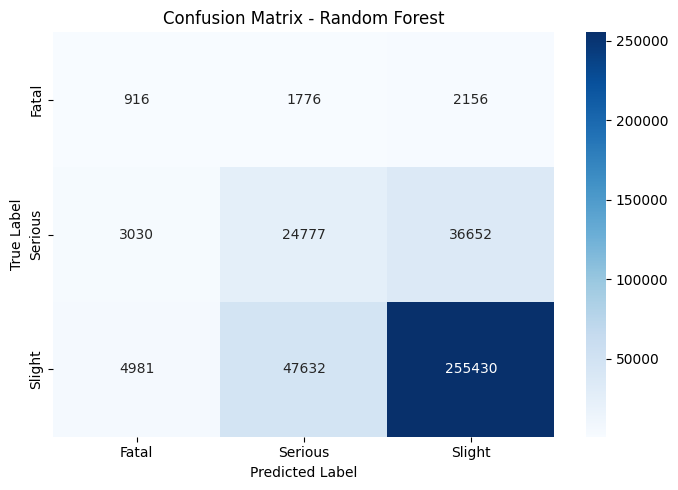

In [38]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fatal", "Serious", "Slight"],
    yticklabels=["Fatal", "Serious", "Slight"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

Replacing special STATS19 missing codes with NaN values did not improve the predictive performance of the models. Therefore, the original encoded values were retained for the final version of the project.

In [39]:
model = RandomForestClassifier(

    n_estimators=300,

    max_depth=30,

    min_samples_split=5,

    min_samples_leaf=2,

    class_weight="balanced_subsample",

    random_state=42,

    n_jobs=-1

)

In [40]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [41]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(1509396, 265)
(377350, 265)


In [42]:
model.fit(X_train_processed, y_train)

print("Generating predictions...")

y_pred_final = model.predict(X_test_processed)

Generating predictions...


In [43]:
print("Final Model Performance")
print("=" * 60)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final, average='macro', zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_final, average='macro'):.4f}")

Final Model Performance
Accuracy:  0.7858
Precision: 0.4730
Recall:    0.4418
F1 Score:  0.4538


In [44]:
print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Fatal", "Serious", "Slight"],
    zero_division=0
))

              precision    recall  f1-score   support

       Fatal       0.17      0.11      0.13      4848
     Serious       0.38      0.33      0.35     64459
      Slight       0.86      0.89      0.88    308043

    accuracy                           0.79    377350
   macro avg       0.47      0.44      0.45    377350
weighted avg       0.77      0.79      0.78    377350



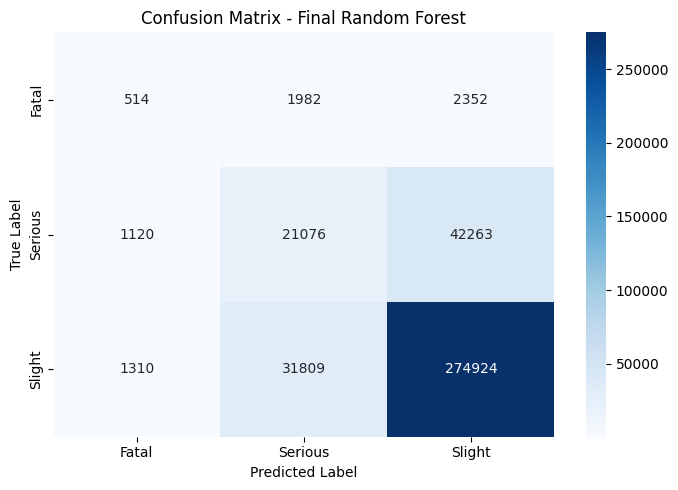

In [45]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fatal", "Serious", "Slight"],
    yticklabels=["Fatal", "Serious", "Slight"]
)

plt.title("Confusion Matrix - Final Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

Save Model

In [46]:
import joblib

joblib.dump(model, "best_model.joblib")
joblib.dump(preprocessor, "preprocessor.joblib")


['preprocessor.joblib']

Final Model

Algorithm:
Random Forest

Training Samples:
1,509,396

Test Samples:
377,350

Features:
265

Accuracy:
78.58%

Macro F1:
45.38%

In [47]:
feature_names = preprocessor.get_feature_names_out()

In [48]:
feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [49]:
feature_importance.head(20)

,Feature,Importance
12,num__max_casualty_age,0.049765
11,num__average_casualty_age,0.046143
3,num__latitude,0.040330
1,num__location_northing_osgr,0.040317
0,num__location_easting_osgr,0.039296
2,num__longitude,0.039196
7,num__average_driver_age,0.038766
8,num__max_driver_age,0.035504
15,num__hour,0.032816
9,num__average_vehicle_age,0.030924


In [50]:
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

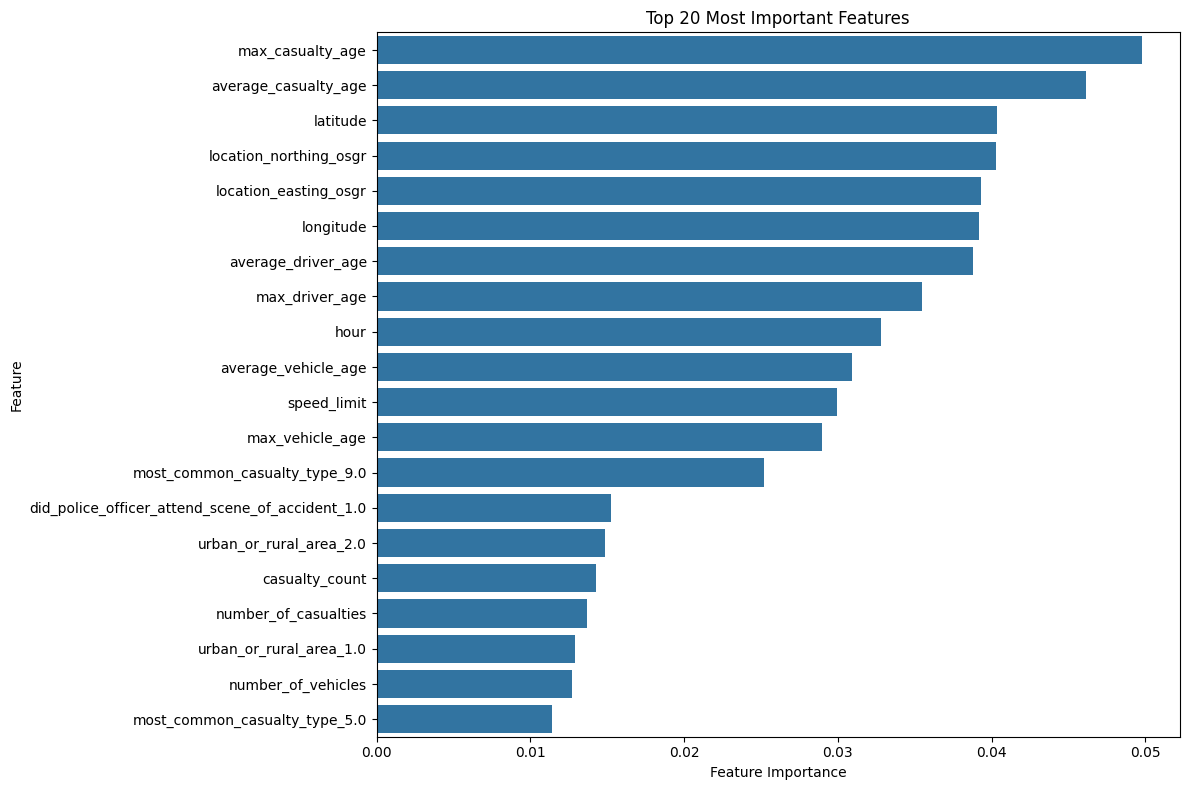

In [51]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature",
    orient="h"
)

plt.title("Top 20 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [52]:
feature_importance.to_csv('feature_importance.csv', index=False)

Feature Importance Summary

The Random Forest model identified casualty age, driver age, geographical location and temporal characteristics as the most influential predictors of collision severity.

Among all variables, the most important predictors include:

- Casualty age
- Driver age
- Geographical coordinates
- Hour of the day
- Speed limit
- Vehicle age
- Number of casualties
- Urban or rural environment

These findings suggest that both human-related factors and environmental conditions play an important role in determining the severity of road traffic collisions.

In [53]:
print("=" * 70)
print("Machine Learning Model Development Completed")
print("=" * 70)

print(f"Training Samples: {X_train.shape[0]:,}")
print(f"Testing Samples: {X_test.shape[0]:,}")
print(f"Final Features: {X_train_processed.shape[1]}")

print("\nFinal Model:")
print("Random Forest Classifier")

print(f"\nAccuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, average='macro', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final, average='macro', zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_final, average='macro'):.4f}")

print("\nThe trained model and preprocessing pipeline have been successfully exported.")

Machine Learning Model Development Completed
Training Samples: 1,509,396
Testing Samples: 377,350
Final Features: 265

Final Model:
Random Forest Classifier

Accuracy : 0.7858
Precision: 0.4730
Recall   : 0.4418
F1 Score : 0.4538

The trained model and preprocessing pipeline have been successfully exported.


In [54]:
print(X_train_processed.shape)
print(model.n_features_in_)

(1509396, 265)
265


Deployment Model

Although the 300-tree Random Forest achieved the best overall performance, the serialized model occupied approximately 5.6 GB, making it impractical for deployment in a Docker container and cloud environments. Therefore, a lighter production model was trained using 100 estimators while maintaining similar predictive performance and significantly reducing the model size.

In [57]:
production_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

production_model.fit(X_train_processed, y_train)

y_pred_prod = production_model.predict(X_test_processed)

print(classification_report(y_test, y_pred_prod))

              precision    recall  f1-score   support

           1       0.16      0.11      0.13      4848
           2       0.38      0.33      0.35     64459
           3       0.86      0.89      0.87    308043

    accuracy                           0.78    377350
   macro avg       0.47      0.44      0.45    377350
weighted avg       0.77      0.78      0.78    377350



In [58]:
joblib.dump(production_model, "production_model.joblib", compress=3)
joblib.dump(preprocessor, "production_preprocessor.joblib")

['production_preprocessor.joblib']